# 01 — Data Preparation

This notebook:
1. Defines all project parameters in one `CONFIG` dictionary
2. Loads BGT and BRT GML files for Arnhem, Wageningen, Apeldoorn
3. Assigns cities to train / val / test splits
4. Encodes categorical class attributes to integers (saved as JSON, not pickle)
5. Tiles each city into fixed-size grid cells
6. Computes per-BGT-polygon **survival labels** by IoU matching against BRT
7. Saves tile GeoJSONs and a tile index for use in later notebooks

**City assignment:**
- Train → Apeldoorn
- Val   → Arnhem
- Test  → Wageningen

**GML / GFS note:**  
Place each `.gfs` file in the same folder as its `.gml` file.  
GDAL picks it up automatically — no code change needed.


## 0. Install dependencies (Colab only)

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install geopandas shapely fiona pyproj --quiet

## 1. CONFIG — edit all parameters here

In [12]:
from pathlib import Path

# ─────────────────────────────────────────────────────────
# PROJECT CONFIG — only edit values in this dictionary
# ─────────────────────────────────────────────────────────
CONFIG = {

    # ── Paths ─────────────────────────────────────────────
    # Expected folder structure:
    #   data_root/
    #     apeldoorn/bgt/wegdeel.gml  (+ wegdeel.gfs, etc.)
    #     apeldoorn/brt/wegdeel.gml
    #     arnhem/bgt/  ...
    #     wageningen/bgt/ ...
    "data_root":   Path("data"),
    "output_root": Path("processed"),

    # ── City → split assignment ────────────────────────────
    "split_map": {
        "apeldoorn":  "train",
        "arnhem":     "val",
        "wageningen": "test",
    },

    # ── CRS ───────────────────────────────────────────────
    "crs": "EPSG:28992",   # RD New — standard for Dutch datasets

    # ── Tiling ────────────────────────────────────────────
    # Tile side length in metres. Larger = more polygons per graph.
    # 500m is a good starting point (~50-200 BGT polygons per tile).
    "tile_size_m": 500,

    # Drop tiles where BGT data covers less than this fraction of the tile
    "tile_min_coverage": 0.3,

    # ── BGT layer files ───────────────────────────────────
    # GML filenames inside each city's bgt/ folder.
    # Place matching .gfs files alongside — GDAL handles them automatically.
    "bgt_layers": [
        "bgt_wegdeel.gml",
        # "onbegroeidterreindeel.gml",
        # "begroeidterreindeel.gml",
        # "waterdeel.gml",
        # "pand.gml",
        # "scheiding.gml",
    ],

    # ── BRT layer files ───────────────────────────────────
    "brt_layers": [
        "top10nl_wegdeel.gml",
        # "terrein.gml",
        # "waterdeel.gml",
        # "gebouw.gml",
    ],

    # ── Class column names ────────────────────────────────
    # Run the column inspection cell after loading to find the right names.
    # BGT GML columns often use dashes, e.g. 'plus-fysiekVoorkomenWegdeel'.
    "bgt_class_col": "plus-fysiekVoorkomenWegdeel",
    "brt_class_col": "verhardingstype",
    "unknown_class": "__UNKNOWN__",

    # ── Survival labelling ────────────────────────────────
    # A BGT polygon is labelled 'survived' if its IoU with the
    # best-matching BRT polygon is >= this threshold.
    "survival_iou_threshold": 0.3,
}

# Create output directories
CONFIG["output_root"].mkdir(parents=True, exist_ok=True)
for split in ["train", "val", "test"]:
    (CONFIG["output_root"] / split).mkdir(exist_ok=True)

print("CONFIG loaded.")
print(f"  data_root   : {CONFIG['data_root'].resolve()}")
print(f"  output_root : {CONFIG['output_root'].resolve()}")
print(f"  splits      : {CONFIG['split_map']}")

CONFIG loaded.
  data_root   : C:\Github\GNN-Map-generalization-BGT-to-BRT\Data
  output_root : C:\Github\GNN-Map-generalization-BGT-to-BRT\processed
  splits      : {'apeldoorn': 'train', 'arnhem': 'val', 'wageningen': 'test'}


## 2. Imports

In [13]:
import json
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.errors import ShapelyDeprecationWarning

warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)
print("Imports OK")

Imports OK


## 3. Load BGT and BRT data

Supports `.gml` and `.shp`. For GML, place the `.gfs` file in the same folder — GDAL picks it up automatically.

In [14]:
def load_layers(city: str, dataset: str, layer_files: list, config: dict) -> gpd.GeoDataFrame:
    """
    Load all GML/SHP layers for one city + dataset (bgt or brt).
    GML files may contain multiple internal layers — all are read.
    Only Polygon/MultiPolygon geometries are kept.
    """
    import fiona
    folder = config["data_root"] / city / dataset
    frames = []

    for layer_file in layer_files:
        path = folder / layer_file
        if not path.exists():
            print(f"  [SKIP] {path} not found")
            continue

        # fiona.listlayers works for both GML and SHP
        try:
            available_layers = fiona.listlayers(str(path))
        except Exception as e:
            print(f"  [WARN] Could not inspect {path.name}: {e}")
            available_layers = [None]

        for layer_name in available_layers:
            try:
                gdf = gpd.read_file(path, layer=layer_name) if layer_name else gpd.read_file(path)
            except Exception as e:
                print(f"  [WARN] Could not read '{layer_name}' from {path.name}: {e}")
                continue

            if len(gdf) == 0:
                continue

            label = path.stem + (f"_{layer_name}" if path.suffix == ".gml" and layer_name else "")
            gdf["source_layer"] = label
            gdf["city"] = city

            if gdf.crs is None:
                print(f"  [WARN] No CRS in {path.name} — assuming {config['crs']}")
                gdf = gdf.set_crs(config["crs"])
            else:
                gdf = gdf.to_crs(config["crs"])

            gdf = gdf[gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
            gdf = gdf[gdf.geometry.is_valid].copy()

            if len(gdf) == 0:
                continue

            frames.append(gdf)
            suffix = f" [{layer_name}]" if layer_name else ""
            print(f"  Loaded {len(gdf):,} polygons from {path.name}{suffix}")

    if not frames:
        raise FileNotFoundError(f"No {dataset} layers found for {city} in {folder}")

    combined = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs=config["crs"])
    print(f"  → {city} {dataset.upper()} total: {len(combined):,} polygons\n")
    return combined


bgt_data, brt_data = {}, {}

for city in CONFIG["split_map"]:
    print(f"Loading {city.upper()} BGT...")
    bgt_data[city] = load_layers(city, "bgt", CONFIG["bgt_layers"], CONFIG)
    print(f"Loading {city.upper()} BRT...")
    brt_data[city] = load_layers(city, "brt", CONFIG["brt_layers"], CONFIG)

print("All data loaded.")

Loading APELDOORN BGT...
  Loaded 520,385 polygons from bgt_wegdeel.gml [TrafficArea]
  → apeldoorn BGT total: 520,385 polygons

Loading APELDOORN BRT...


Skipping field typeWeg: unsupported OGR type: 5
Skipping field hoofdverkeersgebruik: unsupported OGR type: 5
Skipping field naam: unsupported OGR type: 5
Skipping field aWegnummer: unsupported OGR type: 5
Skipping field fysiekVoorkomen: unsupported OGR type: 5
Skipping field nWegnummer: unsupported OGR type: 5


  [WARN] No CRS in top10nl_wegdeel.gml — assuming EPSG:28992
  Loaded 69,748 polygons from top10nl_wegdeel.gml [Wegdeel]
  → apeldoorn BRT total: 69,748 polygons

Loading ARNHEM BGT...
  Loaded 275,935 polygons from bgt_wegdeel.gml [TrafficArea]
  → arnhem BGT total: 275,935 polygons

Loading ARNHEM BRT...


Skipping field typeWeg: unsupported OGR type: 5
Skipping field hoofdverkeersgebruik: unsupported OGR type: 5
Skipping field naam: unsupported OGR type: 5
Skipping field aWegnummer: unsupported OGR type: 5
Skipping field fysiekVoorkomen: unsupported OGR type: 5
Skipping field nWegnummer: unsupported OGR type: 5


  [WARN] No CRS in top10nl_wegdeel.gml — assuming EPSG:28992
  Loaded 54,360 polygons from top10nl_wegdeel.gml [Wegdeel]
  → arnhem BRT total: 54,360 polygons

Loading WAGENINGEN BGT...
  Loaded 76,869 polygons from bgt_wegdeel.gml [TrafficArea]
  → wageningen BGT total: 76,869 polygons

Loading WAGENINGEN BRT...


Skipping field typeWeg: unsupported OGR type: 5
Skipping field hoofdverkeersgebruik: unsupported OGR type: 5
Skipping field naam: unsupported OGR type: 5
Skipping field nWegnummer: unsupported OGR type: 5


  [WARN] No CRS in top10nl_wegdeel.gml — assuming EPSG:28992
  Loaded 16,368 polygons from top10nl_wegdeel.gml [Wegdeel]
  → wageningen BRT total: 16,368 polygons

All data loaded.


In [15]:
# ── Column inspection ─────────────────────────────────────────────────────────
# Check real column names before encoding. BGT GML often uses dashes.
# Update bgt_class_col / brt_class_col in CONFIG if either shows ✗.
train_city = [c for c, s in CONFIG["split_map"].items() if s == "train"][0]

skip = {"geometry", "city", "source_layer"}
print(f"BGT columns ({train_city}):")
print(" ", [c for c in bgt_data[train_city].columns if c not in skip])
print(f"\nBRT columns ({train_city}):")
print(" ", [c for c in brt_data[train_city].columns if c not in skip])

bgt_ok = CONFIG["bgt_class_col"] in bgt_data[train_city].columns
brt_ok = CONFIG["brt_class_col"] in brt_data[train_city].columns
print(f"\nbgt_class_col '{CONFIG['bgt_class_col']}': {'✓' if bgt_ok else '✗  UPDATE CONFIG'}")
print(f"brt_class_col '{CONFIG['brt_class_col']}': {'✓' if brt_ok else '✗  UPDATE CONFIG'}")

BGT columns (apeldoorn):
  ['gml_id', 'creationDate', 'LV-publicatiedatum', 'relatieveHoogteligging', 'inOnderzoek', 'eindRegistratie', 'tijdstipRegistratie', 'namespace', 'lokaalID', 'bronhouder', 'bgt-status', 'plus-status', 'function', 'surfaceMaterial', 'kruinlijnWegdeel', 'wegdeelOpTalud', 'plus-fysiekVoorkomenWegdeel', 'plus-functieWegdeel', 'terminationDate']

BRT columns (apeldoorn):
  ['gml_id', 'namespace', 'lokaalID', 'brontype', 'bronactualiteit', 'bronbeschrijving', 'bronnauwkeurigheid', 'objectBeginTijd', 'tijdstipRegistratie', 'tdnCode', 'visualisatieCode', 'typeInfrastructuur', 'verhardingsbreedteklasse', 'gescheidenRijbaan', 'verhardingstype', 'hoogteniveau', 'status', 'mutatieType', 'isBAGnaam', 'aantalRijstroken', 'afritnummer', 'brugnaam', 'eWegnummer', 'knooppuntnaam', 'tunnelnaam']

bgt_class_col 'plus-fysiekVoorkomenWegdeel': ✓
brt_class_col 'verhardingstype': ✓


## 4. Build label encoders (saved as JSON)

In [16]:
class LabelEncoder:
    """
    String → integer encoder.
    Fitted on training city only to prevent data leakage.
    Saved as plain JSON so any notebook can load it without pickle.
    """

    def __init__(self, unknown_label="__UNKNOWN__"):
        self.unknown_label = unknown_label
        self.classes_      = []
        self.label_to_int  = {}
        self.int_to_label  = {}
        self._fitted       = False

    def fit(self, series: pd.Series):
        unique = sorted(series.dropna().unique().tolist())
        self.classes_     = [self.unknown_label] + unique
        self.label_to_int = {c: i for i, c in enumerate(self.classes_)}
        self.int_to_label = {i: c for i, c in enumerate(self.classes_)}
        self._fitted      = True
        return self

    def transform(self, series: pd.Series) -> pd.Series:
        assert self._fitted
        return series.map(lambda x: self.label_to_int.get(x, 0)).astype(int)

    def inverse_transform(self, series: pd.Series) -> pd.Series:
        assert self._fitted
        return series.map(lambda x: self.int_to_label.get(x, self.unknown_label))

    def save(self, path):
        data = {
            "unknown_label": self.unknown_label,
            "classes":       self.classes_,
            "label_to_int":  self.label_to_int,
            "int_to_label":  {str(k): v for k, v in self.int_to_label.items()},
        }
        with open(path, "w") as f:
            json.dump(data, f, indent=2)

    def __repr__(self):
        return f"LabelEncoder({len(self.classes_)} classes)"


def load_encoder(path):
    """Load encoder from JSON — no pickle, no class dependency."""
    with open(path) as f:
        data = json.load(f)
    enc = LabelEncoder(unknown_label=data["unknown_label"])
    enc.classes_     = data["classes"]
    enc.label_to_int = data["label_to_int"]
    enc.int_to_label = {int(k): v for k, v in data["int_to_label"].items()}
    enc._fitted      = True
    return enc


train_city = [c for c, s in CONFIG["split_map"].items() if s == "train"][0]
bgt_col    = CONFIG["bgt_class_col"]
brt_col    = CONFIG["brt_class_col"]

bgt_encoder = LabelEncoder(CONFIG["unknown_class"])
brt_encoder = LabelEncoder(CONFIG["unknown_class"])

if bgt_col in bgt_data[train_city].columns:
    bgt_encoder.fit(bgt_data[train_city][bgt_col].fillna(CONFIG["unknown_class"]))
    print(f"BGT encoder: {bgt_encoder}")
else:
    print(f"[WARN] BGT column '{bgt_col}' not found — encoder will be empty")

if brt_col in brt_data[train_city].columns:
    brt_encoder.fit(brt_data[train_city][brt_col].fillna(CONFIG["unknown_class"]))
    print(f"BRT encoder: {brt_encoder}")
else:
    print(f"[WARN] BRT column '{brt_col}' not found — encoder will be empty")

bgt_encoder.save(CONFIG["output_root"] / "bgt_encoder.json")
brt_encoder.save(CONFIG["output_root"] / "brt_encoder.json")
print("\nEncoders saved as JSON.")

BGT encoder: LabelEncoder(16 classes)
BRT encoder: LabelEncoder(5 classes)

Encoders saved as JSON.


In [17]:
def apply_encoding(gdf: gpd.GeoDataFrame, col: str, encoder: LabelEncoder) -> gpd.GeoDataFrame:
    """Add '<col>_encoded' integer column to gdf."""
    gdf = gdf.copy()
    if col in gdf.columns:
        gdf[f"{col}_encoded"] = encoder.transform(gdf[col].fillna(encoder.unknown_label))
    else:
        print(f"  [WARN] Column '{col}' not found — encoding as 0")
        gdf[f"{col}_encoded"] = 0
    return gdf

for city in CONFIG["split_map"]:
    bgt_data[city] = apply_encoding(bgt_data[city], bgt_col, bgt_encoder)
    brt_data[city] = apply_encoding(brt_data[city], brt_col, brt_encoder)
    print(f"Encoded {city}")

print("\nEncoding complete.")

Encoded apeldoorn
Encoded arnhem
Encoded wageningen

Encoding complete.


## 5. Tiling

In [18]:
def make_tile_grid(gdf: gpd.GeoDataFrame, tile_size: float, crs: str) -> gpd.GeoDataFrame:
    """Regular square grid covering the bounding box of gdf."""
    minx, miny, maxx, maxy = gdf.total_bounds
    tiles = [
        {"geometry": box(x, y, x + tile_size, y + tile_size), "tile_x": x, "tile_y": y}
        for x in np.arange(minx, maxx, tile_size)
        for y in np.arange(miny, maxy, tile_size)
    ]
    grid = gpd.GeoDataFrame(tiles, crs=crs)
    grid["tile_id"] = range(len(grid))
    return grid


def filter_tiles_by_coverage(grid, data, min_coverage):
    """Remove tiles covered by less than min_coverage fraction of data."""
    tile_area = grid.geometry.iloc[0].area
    joined    = gpd.sjoin(grid, data[["geometry"]], how="left", predicate="intersects")
    data_area = (
        joined.groupby("tile_id")
        .apply(lambda g: gpd.GeoDataFrame(g, crs=grid.crs).geometry.area.sum())
        .rename("data_area")
    )
    grid = grid.join(data_area, on="tile_id")
    grid["coverage"] = grid["data_area"].fillna(0) / tile_area
    return grid[grid["coverage"] >= min_coverage].copy()


print("Tiling functions defined.")

Tiling functions defined.


## 6. Compute survival labels

For each BGT polygon, find the best-matching BRT polygon by IoU.  
Label = 1 (survived) if max IoU ≥ threshold, else 0 (dropped).
This is the target the GNN will learn to predict.

In [19]:
def compute_survival_labels(bgt: gpd.GeoDataFrame,
                             brt: gpd.GeoDataFrame,
                             iou_threshold: float) -> gpd.GeoDataFrame:
    """
    Add 'survived' (0/1) and 'max_iou' columns to bgt.

    Strategy:
      1. Spatial join to find candidate BGT-BRT polygon pairs (intersects)
      2. Compute IoU for each candidate pair
      3. Take max IoU per BGT polygon
      4. survived = 1 if max_iou >= iou_threshold
    """
    bgt = bgt.copy().reset_index(drop=True)
    brt = brt.copy().reset_index(drop=True)

    if len(bgt) == 0 or len(brt) == 0:
        bgt["max_iou"]  = 0.0
        bgt["survived"] = 0
        return bgt

    # Spatial join: each BGT polygon gets candidate BRT neighbours
    joined = gpd.sjoin(
        bgt[["geometry"]].reset_index().rename(columns={"index": "bgt_idx"}),
        brt[["geometry"]].reset_index().rename(columns={"index": "brt_idx"}),
        how="left", predicate="intersects"
    )

    def iou(a, b):
        try:
            inter = a.intersection(b).area
            union = a.union(b).area
            return inter / union if union > 0 else 0.0
        except Exception:
            return 0.0

    # Compute IoU for each candidate pair
    ious = []
    for _, row in joined.iterrows():
        brt_idx = row.get("brt_idx")
        if pd.isna(brt_idx):
            ious.append(0.0)
        else:
            ious.append(iou(bgt.geometry.iloc[int(row["bgt_idx"])],
                            brt.geometry.iloc[int(brt_idx)]))
    joined["iou"] = ious

    # Max IoU per BGT polygon
    max_iou = joined.groupby("bgt_idx")["iou"].max()
    bgt["max_iou"]  = bgt.index.map(max_iou).fillna(0.0)
    bgt["survived"] = (bgt["max_iou"] >= iou_threshold).astype(int)
    return bgt


print("Survival label function defined.")

Survival label function defined.


## 7. Build and save tile pairs

In [20]:
tile_summary = {}

for city, split in CONFIG["split_map"].items():
    print(f"\nTiling {city.upper()} → {split}")

    bgt = bgt_data[city]
    brt = brt_data[city]

    grid = make_tile_grid(bgt, CONFIG["tile_size_m"], CONFIG["crs"])
    print(f"  Initial grid : {len(grid)} tiles")
    grid = filter_tiles_by_coverage(grid, bgt, CONFIG["tile_min_coverage"])
    print(f"  After filter : {len(grid)} tiles")

    out_dir = CONFIG["output_root"] / split / city
    out_dir.mkdir(parents=True, exist_ok=True)

    saved = 0
    for _, tile_row in grid.iterrows():
        tile_id   = tile_row["tile_id"]
        tile_geom = tile_row["geometry"]

        bgt_tile = gpd.clip(bgt, tile_geom).reset_index(drop=True)
        brt_tile = gpd.clip(brt, tile_geom).reset_index(drop=True)

        if len(bgt_tile) == 0 or len(brt_tile) == 0:
            continue

        # Compute survival labels for this tile's BGT polygons
        bgt_tile = compute_survival_labels(
            bgt_tile, brt_tile, CONFIG["survival_iou_threshold"]
        )

        bgt_tile.to_file(out_dir / f"tile_{tile_id:04d}_bgt.geojson", driver="GeoJSON")
        brt_tile.to_file(out_dir / f"tile_{tile_id:04d}_brt.geojson", driver="GeoJSON")
        saved += 1

    tile_summary[city] = {"split": split, "tiles_saved": saved}
    print(f"  Saved {saved} tile pairs")

print("\n── Tile summary ──")
for city, info in tile_summary.items():
    print(f"  {city:12s} [{info['split']:5s}]  {info['tiles_saved']} tile pairs")


Tiling APELDOORN → train
  Initial grid : 3619 tiles


C:\Users\jurre\AppData\Local\Temp\ipykernel_6012\4180762140.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: gpd.GeoDataFrame(g, crs=grid.crs).geometry.area.sum())


  After filter : 3619 tiles
  Saved 2561 tile pairs

Tiling ARNHEM → val
  Initial grid : 2052 tiles


C:\Users\jurre\AppData\Local\Temp\ipykernel_6012\4180762140.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: gpd.GeoDataFrame(g, crs=grid.crs).geometry.area.sum())


  After filter : 2052 tiles
  Saved 1308 tile pairs

Tiling WAGENINGEN → test
  Initial grid : 736 tiles


C:\Users\jurre\AppData\Local\Temp\ipykernel_6012\4180762140.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: gpd.GeoDataFrame(g, crs=grid.crs).geometry.area.sum())


  After filter : 736 tiles
  Saved 532 tile pairs

── Tile summary ──
  apeldoorn    [train]  2561 tile pairs
  arnhem       [val  ]  1308 tile pairs
  wageningen   [test ]  532 tile pairs


## 8. Save tile index

In [21]:
index = {"train": [], "val": [], "test": []}

for city, split in CONFIG["split_map"].items():
    city_dir = CONFIG["output_root"] / split / city
    for bgt_path in sorted(city_dir.glob("*_bgt.geojson")):
        brt_path = Path(str(bgt_path).replace("_bgt.geojson", "_brt.geojson"))
        if brt_path.exists():
            index[split].append({"city": city, "bgt": str(bgt_path), "brt": str(brt_path)})

index_path = CONFIG["output_root"] / "tile_index.json"
with open(index_path, "w") as f:
    json.dump(index, f, indent=2)

print(f"Tile index saved → {index_path}")
for split, tiles in index.items():
    print(f"  {split:5s}: {len(tiles)} tiles")

Tile index saved → processed\tile_index.json
  train: 2561 tiles
  val  : 1308 tiles
  test : 532 tiles


## 9. Sanity plot

C:\Users\jurre\AppData\Local\Temp\ipykernel_6012\3951024237.py:15: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  survived.plot(ax=ax, color="steelblue", alpha=0.6)
C:\Users\jurre\AppData\Local\Temp\ipykernel_6012\3951024237.py:15: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  survived.plot(ax=ax, color="steelblue", alpha=0.6)


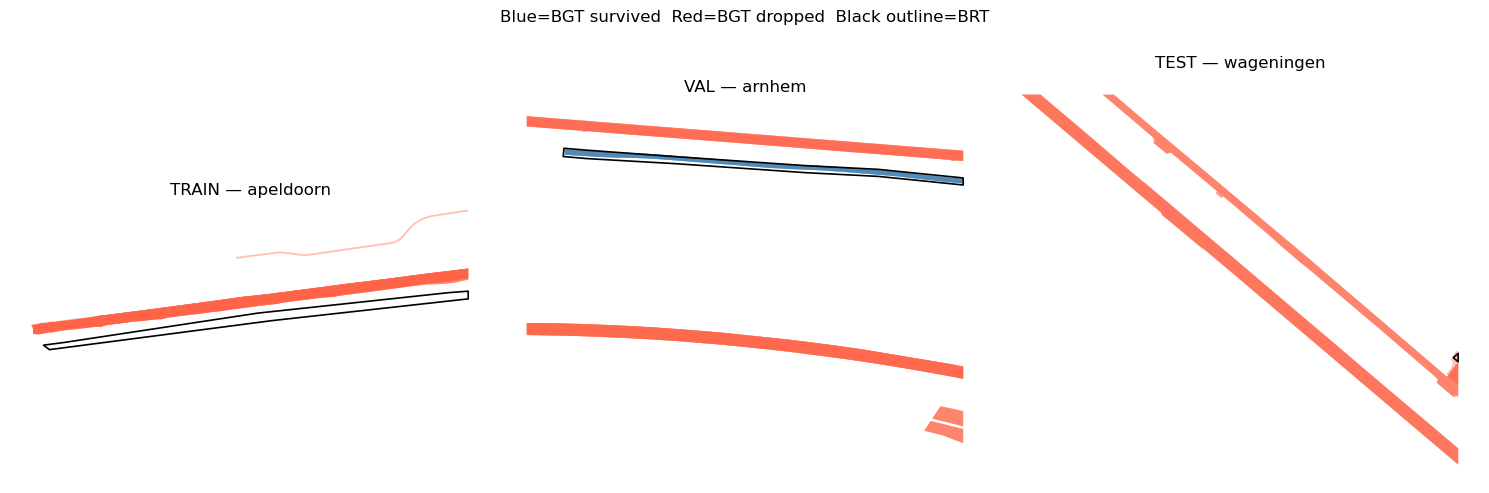

Sanity plot saved.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (split, tiles) in zip(axes, index.items()):
    if not tiles:
        ax.set_title(f"{split} — no tiles")
        continue
    first   = tiles[0]
    bgt_t   = gpd.read_file(first["bgt"])
    brt_t   = gpd.read_file(first["brt"])

    # Colour BGT polygons by survival label
    survived = bgt_t[bgt_t["survived"] == 1] if "survived" in bgt_t.columns else bgt_t
    dropped  = bgt_t[bgt_t["survived"] == 0] if "survived" in bgt_t.columns else gpd.GeoDataFrame()

    survived.plot(ax=ax, color="steelblue", alpha=0.6)
    if len(dropped) > 0:
        dropped.plot(ax=ax, color="tomato", alpha=0.4)
    brt_t.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2)

    ax.set_title(f"{split.upper()} — {first['city']}")
    ax.set_axis_off()

plt.suptitle("Blue=BGT survived  Red=BGT dropped  Black outline=BRT", y=1.01)
plt.tight_layout()
plt.savefig(CONFIG["output_root"] / "sanity_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sanity plot saved.")